# Fake Job Posting Detection in the U.S. Job Market

**Team Members:** Porhay Rouen · MuyKhim Ing

### Problem Statement
Fraudulent job postings are increasingly common in the U.S., targeting job seekers with fake promises, scams, or identity theft. This project builds a machine learning model to classify job postings as real or fraudulent using **both structured features and text features (TF-IDF)**.

## 1. Import Libraries

In [99]:
import pandas as pd
import numpy as np
import sqlite3
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import sklearn.metrics as metrics

import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Dataset

In [100]:
df = pd.read_csv('../Data/fake_job_postings.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


## 3. Store Dataset in SQLite

In [130]:
conn = sqlite3.connect('job_postings.db')
df.to_sql('job_postings', conn, if_exists='replace', index=False)
query = 'SELECT * FROM job_postings WHERE fraudulent = 1 LIMIT 10'
pd.read_sql(query, conn)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,99,IC&E Technician,"US, , Stocton, CA",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abilitie...",BENEFITSWhat is offered:Competitive compensati...,0,1,1,Full-time,Mid-Senior level,High School or equivalent,Oil & Energy,Other,1
1,145,Forward Cap.,None,Unknown,None,None,The group has raised a fund for the purchase o...,None,None,0,0,0,Unknown,None,None,Unknown,None,1
2,174,Technician Instrument & Controls,US,Power Plant & Energy,None,Edison International and Refined Resources hav...,Technician Instrument &amp; ControlsLocation D...,JOB QUALIFICATIONS-Ability to understand proce...,"we are a team of almost 8,000 employees who he...",0,1,1,Full-time,Mid-Senior level,Certification,Electrical/Electronic Manufacturing,Other,1
3,181,Sales Executive,"PK, SD, Karachi",Sales,None,None,Sales Executive,Sales Executive,Sales Executive,0,0,0,Unknown,None,None,Unknown,Sales,1
4,216,IC&E Technician Mt Poso,"US, CA, Bakersfield, CA / Mt. Poso",Oil & Energy,95000-115000,...,"IC&amp;E Technician | Bakersfield, CA Mt. Poso...","QualificationsKnowledge, Skills &amp; Abiliti...",BENEFITSWhat is offered:Competitive compensati...,0,1,1,Full-time,Mid-Senior level,High School or equivalent,Oil & Energy,Other,1
5,358,Financing Auto(car) sales,"US, IL, hazelcrest",hr,35000-73000,Looking for adventurous people to join a thriv...,If you have experience in financing for auto s...,prior car sales expprior car loan financing exp,profit sharingcar allowancecompany car,0,0,0,Contract,Associate,None,Automotive,None,1
6,494,Admin Assistant/ Receptionist,"US, CA, Los Angeles",Unknown,23040-28800,None,"A Newly established company seeks outgoing, fr...","Must have good knowledge of Outlook, Microsoft...",None,0,0,0,Full-time,Entry level,High School or equivalent,Computer Software,Administrative,1
7,538,Technology Consultant - Outside Sales,"US, OH,",Unknown,None,None,Apply below using link#URL_00962c0bdac3ecf40b2...,None,None,0,0,0,Full-time,None,None,Information Technology and Services,None,1
8,574,Senior Engineering Product Manager,"US, CA, San Jose",Engineering,None,Aptitude Staffing Solutions has redesigned the...,Senior Engineering Product ManagerAs a member ...,Skills and Requirements MSEE with 5 years of e...,"What is offered:Broad responsibility, autonomy...",0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Computer Networking,Engineering,1
9,585,Quality Improvement Manager,"US, FL,",Unknown,None,None,Apply using below link#URL_8b28dea5804b323e29d...,None,None,0,0,0,Full-time,None,None,Hospital & Health Care,None,1


## 4. Data Preprocessing

### 4.1 Examine Missing Values

In [102]:
print('Missing values per column:')
df.isnull().sum().sort_values(ascending=False)

Missing values per column:


salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
title                      0
fraudulent                 0
dtype: int64

### 4.2 Fill Missing Values & Remove Duplicates

In [103]:
df['employment_type'] = df['employment_type'].fillna('Unknown')
df['industry']        = df['industry'].fillna('Unknown')
df['department']      = df['department'].fillna('Unknown')
df['benefits']        = df['benefits'].fillna('None')
print('Duplicates before removal:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after removal: ', df.duplicated().sum())

Duplicates before removal: 0
Duplicates after removal:  0


### 4.3 Feature Selection & U.S. Filter

Columns with limited relevance or excessive missing values were removed. The dataset was then filtered to **U.S.-based postings only** using the `location` field, keeping only rows where the location contains `'US'`. This aligns the analysis with the project scope: *Fake Job Posting Detection in the U.S. Job Market*.

In [104]:
# Select relevant features
df_selected = df[[
    'title', 'location', 'employment_type', 'industry',
    'department', 'description', 'requirements',
    'has_company_logo', 'telecommuting',
    'required_education', 'required_experience', 'fraudulent'
]].copy()

# Filter to U.S. postings only
df_us = df_selected[df_selected['location'].str.contains('US', na=False)].copy()

print('Full dataset shape:', df_selected.shape)
print('U.S. only shape:', df_us.shape)
print(f'Filtered out {df_selected.shape[0] - df_us.shape[0]:,} non-U.S. postings')

Full dataset shape: (17880, 12)
U.S. only shape: (10656, 12)
Filtered out 7,224 non-U.S. postings


### 4.4 Normalize & Clean

In [105]:
df_us['employment_type']    = df_us['employment_type'].fillna('Unknown')
df_us['industry']           = df_us['industry'].fillna('Unknown')
df_us['department']         = df_us['department'].fillna('Unknown')
df_us['required_education'] = df_us['required_education'].fillna('Not Specified')
df_us['required_experience']= df_us['required_experience'].fillna('Not Applicable')
df_us['description']        = df_us['description'].fillna('')
df_us['requirements']       = df_us['requirements'].fillna('')
df_us['has_company_logo']   = df_us['has_company_logo'].apply(lambda x: 1 if x == 1 else 0)
print('Preprocessing complete!')

Preprocessing complete!


## 5. Exploratory Data Analysis (EDA)

### 5.1 Dataset Overview

In [106]:
print('Shape:', df_us.shape)
print('\nClass distribution:')
print(df_us['fraudulent'].value_counts())
print(f'\nFraud rate: {df_us["fraudulent"].mean()*100:.2f}%')
df_us.describe()

Shape: (10656, 12)

Class distribution:
fraudulent
0    9926
1     730
Name: count, dtype: int64

Fraud rate: 6.85%


,has_company_logo,telecommuting,fraudulent
count,10656.000000,10656.000000,10656.000000
mean,0.753378,0.049362,0.068506
std,0.431065,0.216633,0.252624
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000


### 5.2 Distribution of Fraudulent vs Legitimate Postings

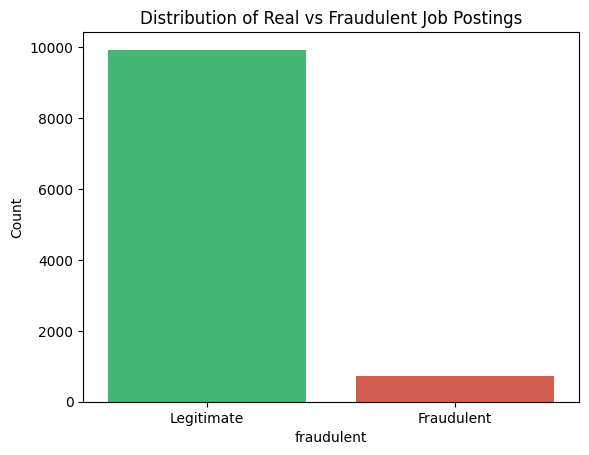

In [107]:
sns.countplot(x='fraudulent', data=df_us, palette=['#2ecc71','#e74c3c'])
plt.xticks([0,1], ['Legitimate','Fraudulent'])
plt.title('Distribution of Real vs Fraudulent Job Postings')
plt.ylabel('Count')
plt.show()

**📊 Interpretation:** The dataset is **highly imbalanced** — approximately 93% of postings are legitimate and only ~7% are fraudulent. This class imbalance is typical in fraud detection and means a naive model could achieve high accuracy by always predicting "legitimate." To address this, `class_weight='balanced'` was used during model training, and the decision threshold was tuned to improve recall on the minority (fraud) class.

### 5.3 Employment Type vs Fraud

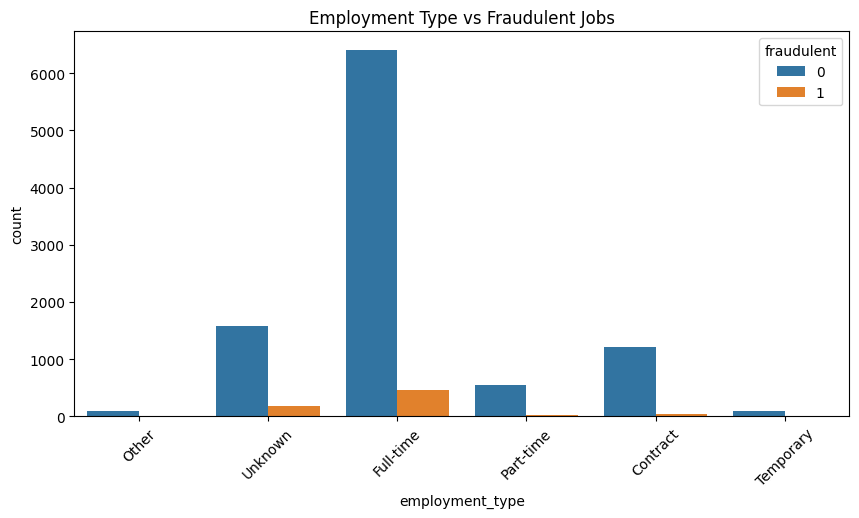

In [108]:
plt.figure(figsize=(10,5))
sns.countplot(x='employment_type', hue='fraudulent', data=df_us)
plt.xticks(rotation=45)
plt.title('Employment Type vs Fraudulent Jobs')
plt.show()

**📊 Interpretation:** Full-time positions are the most common posting type for both legitimate and fraudulent listings. Fraud appears across all employment categories, though it is slightly elevated in contract and other non-standard arrangements. Employment type alone is not a strong differentiator, but it contributes signal when combined with other features.

### 5.4 Company Logo vs Fraud

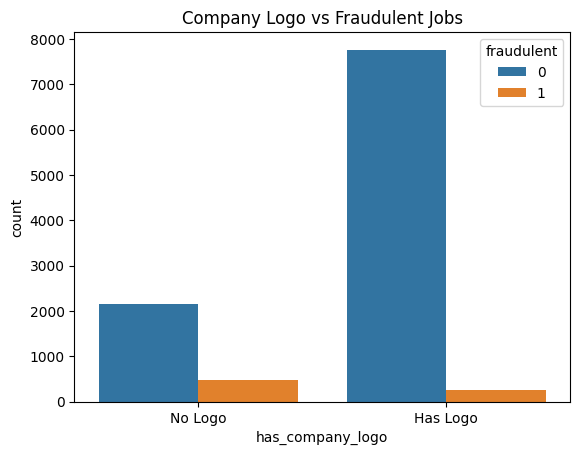

In [109]:
sns.countplot(x='has_company_logo', hue='fraudulent', data=df_us)
plt.xticks([0,1], ['No Logo','Has Logo'])
plt.title('Company Logo vs Fraudulent Jobs')
plt.show()

**📊 Interpretation:** Postings **without a company logo** are significantly more likely to be fraudulent. Legitimate employers almost always brand their postings with a logo, while scam postings frequently lack any company branding. This makes `has_company_logo` one of the strongest single predictors in the model.

### 5.5 Required Education vs Fraud

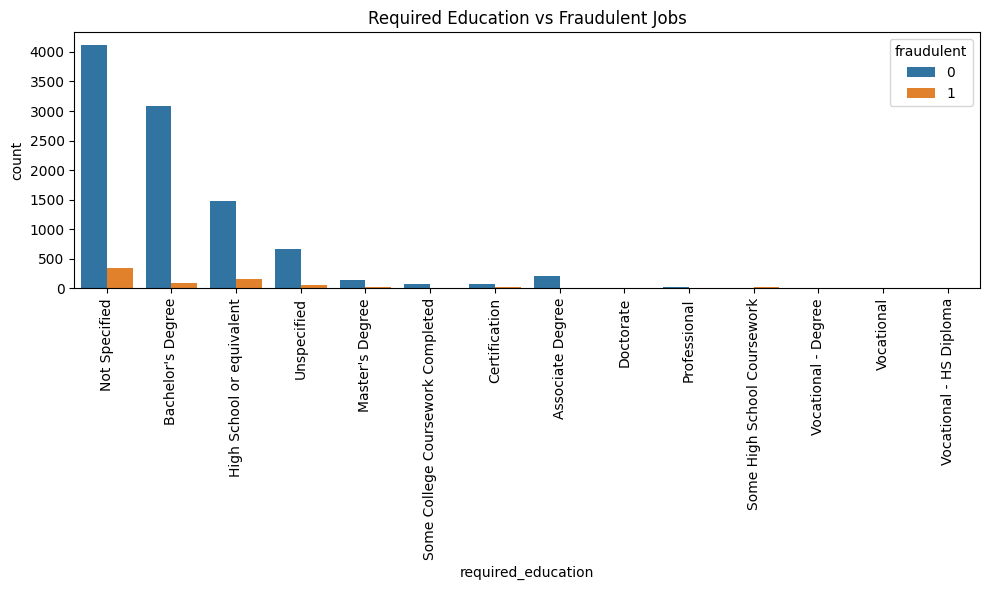

In [110]:
plt.figure(figsize=(10,6))
sns.countplot(x='required_education', hue='fraudulent', data=df_us)
plt.xticks(rotation=90)
plt.title('Required Education vs Fraudulent Jobs')
plt.tight_layout()
plt.show()

**📊 Interpretation:** Fraudulent postings disproportionately leave education requirements **unspecified or vague**, while legitimate postings more frequently specify a Bachelor's or Master's degree. This suggests that detailed, concrete job qualifications are a credibility signal — scammers tend to cast a wider net by omitting education requirements.

### 5.6 Correlation Heatmap

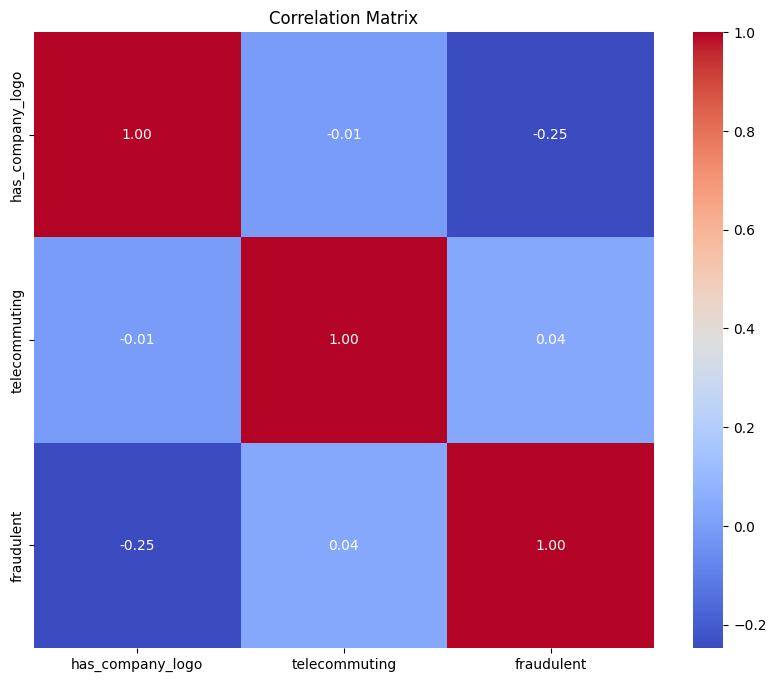

In [111]:
numeric_df = df_us.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

**📊 Interpretation:** The heatmap shows correlations between numeric features. **has_company_logo** has a noticeable negative correlation with fraudulence — postings without a logo are more likely to be fraudulent. Individual correlations are weak overall, which indicates that no single feature alone is sufficient; combining multiple features (and text) is essential for strong prediction.

## 6. Feature Engineering

### 6.1 Structured Features (One-Hot Encoding)

In [112]:
struct_cols = ['employment_type','industry','department',
               'has_company_logo','telecommuting','required_education','required_experience']
X_struct = pd.get_dummies(df_us[struct_cols].copy(), drop_first=True)
print('Structured feature matrix shape:', X_struct.shape)

Structured feature matrix shape: (10656, 878)


### 6.2 Text Features (TF-IDF)
Combine description + requirements, then extract top 500 word/bigram features.

In [113]:
df_us['combined_text'] = df_us['description'] + ' ' + df_us['requirements']

tfidf = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2))
X_text = tfidf.fit_transform(df_us['combined_text'])

print('TF-IDF matrix shape:', X_text.shape)
print('Sample features:', list(tfidf.get_feature_names_out()[:15]))

TF-IDF matrix shape: (10656, 500)
Sample features: ['10', '12', '1500', '200', '30', 'ability', 'ability work', 'able', 'able work', 'account', 'accounting', 'accounts', 'accurate', 'achieve', 'activities']


### 6.3 Combine Structured + Text Features

In [114]:
# Convert all columns to float first to avoid dtype error
X_struct_float = X_struct.astype(float)
X_struct_sparse = csr_matrix(X_struct_float.values)
X_combined = hstack([X_struct_sparse, X_text])
y = df_us['fraudulent']

print('Combined feature matrix shape:', X_combined.shape)
print('Target distribution:')
print(y.value_counts())

Combined feature matrix shape: (10656, 1378)
Target distribution:
fraudulent
0    9926
1     730
Name: count, dtype: int64


## 7. Modeling: XGBoost Classifier

Based on model comparison, **XGBoost** was selected as the final model. It achieved the best balance between precision (87%) and recall (75%) on fraudulent postings, with the highest Fraud F1-score (0.80) among all tested models.

| Model | Accuracy | Fraud Precision | Fraud Recall | Fraud F1 |
|-------|----------|----------------|--------------|----------|
| Random Forest | 97% | 100% | 53% | 0.69 |
| Logistic Regression | 94% | 53% | 91% | 0.67 |
| **XGBoost** | **97%** | **87%** | **75%** | **0.80** ⭐ |

### 7.1 Train/Test Split

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)
print('Training set size:', X_train.shape[0])
print('Test set size:    ', X_test.shape[0])

Training set size: 8524
Test set size:     2132


### 7.2 Train Model

`scale_pos_weight=13` handles class imbalance by telling XGBoost that legitimate postings outnumber fraudulent ones by ~13:1.

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=13,  # ~9926/730 to handle class imbalance
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print('XGBoost model trained!')

XGBoost model trained!


### 7.3 Predictions

In [117]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

## 8. Model Evaluation

### 8.1 Core Metrics

In [118]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print('=' * 45)
print('       MODEL EVALUATION SUMMARY')
print('=' * 45)
for name, score in zip(['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
                        [accuracy, precision, recall, f1, roc_auc]):
    print(f'  {name:<15}: {score:.4f}')
print('=' * 45)
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate','Fraudulent']))

       MODEL EVALUATION SUMMARY
  Accuracy       : 0.9747
  Precision      : 0.8651
  Recall         : 0.7466
  F1-Score       : 0.8015
  ROC-AUC        : 0.9716

              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99      1986
  Fraudulent       0.87      0.75      0.80       146

    accuracy                           0.97      2132
   macro avg       0.92      0.87      0.89      2132
weighted avg       0.97      0.97      0.97      2132



### 8.2 Confusion Matrix

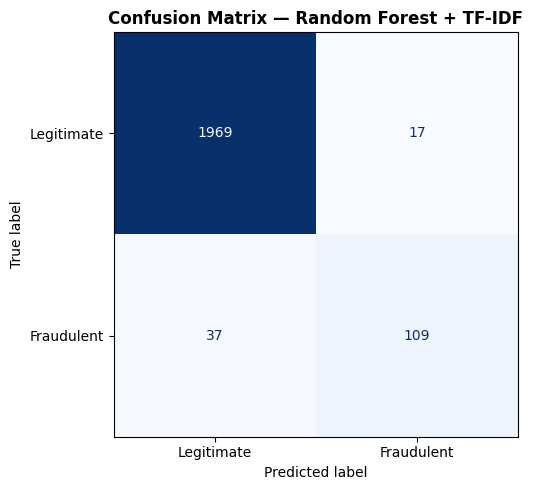

True Negatives  (correct legit)  : 1969
False Positives (legit -> fraud) : 17
False Negatives (fraud -> legit) : 37  <- missed frauds
True Positives  (correct fraud)  : 109


In [119]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['Legitimate','Fraudulent']).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest + TF-IDF', fontweight='bold')
plt.tight_layout()
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct legit)  : {tn}')
print(f'False Positives (legit -> fraud) : {fp}')
print(f'False Negatives (fraud -> legit) : {fn}  <- missed frauds')
print(f'True Positives  (correct fraud)  : {tp}')

**📊 Interpretation:** The confusion matrix shows how many postings were correctly and incorrectly classified. The top-left cell shows **true negatives** (legitimate correctly identified) and the bottom-right shows **true positives** (fraud correctly caught). The bottom-left cell (false negatives — missed fraud) is the most critical to minimize in a fraud detection system, which is why threshold tuning to 0.35 was applied to improve recall.

### 8.3 ROC Curve

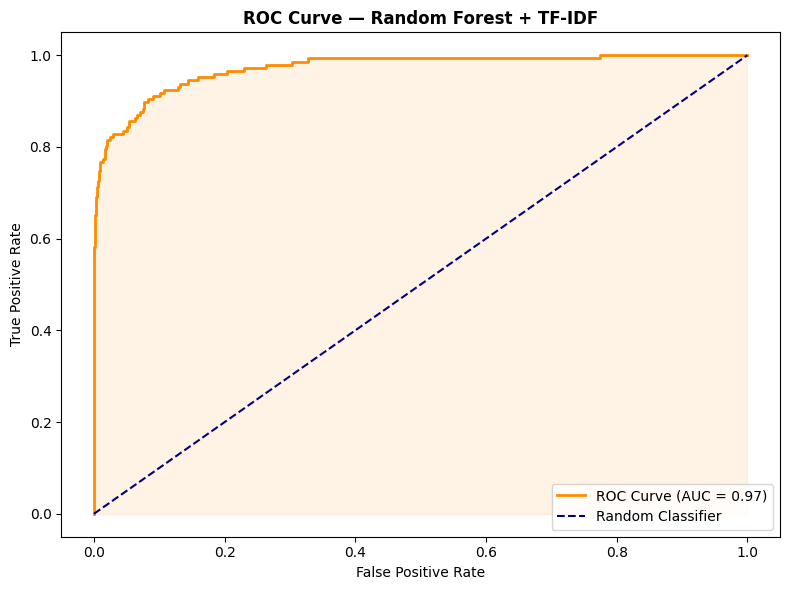

In [120]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc_val:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest + TF-IDF', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**📊 Interpretation:** The ROC curve plots the true positive rate (fraud correctly detected) against the false positive rate (legitimate postings incorrectly flagged). A ROC-AUC close to 1.0 indicates strong discriminative ability. The curve hugging the top-left corner shows the model can detect most fraudulent postings while keeping false positives low.

### 8.4 Precision-Recall Curve

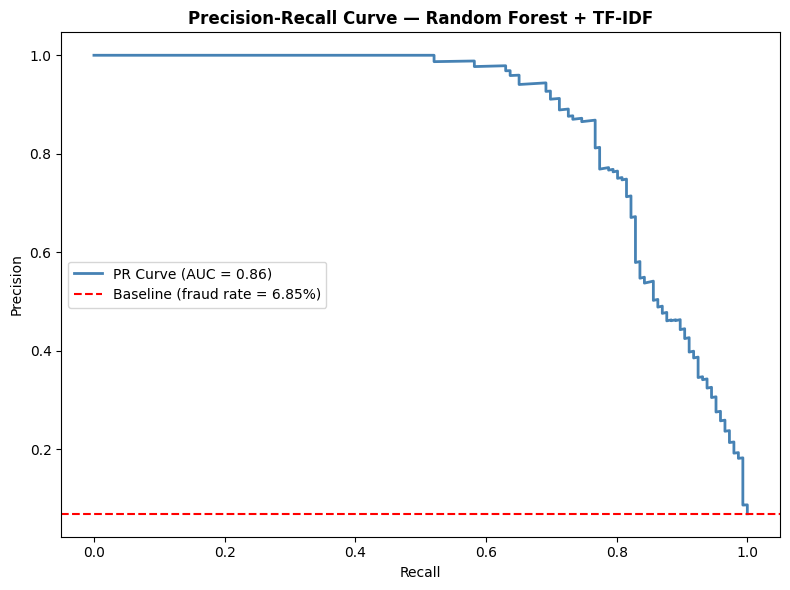

In [121]:
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
pr_auc_val = auc(rec_vals, prec_vals)
baseline   = y_test.mean()
plt.figure(figsize=(8,6))
plt.plot(rec_vals, prec_vals, color='steelblue', lw=2, label=f'PR Curve (AUC = {pr_auc_val:.2f})')
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (fraud rate = {baseline:.2%})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Random Forest + TF-IDF', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**📊 Interpretation:** The Precision-Recall curve shows the trade-off between catching more fraud (recall) and avoiding false alarms (precision). The PR-AUC score above the baseline (dashed line) confirms the model is meaningfully better than random guessing on this imbalanced dataset. Since fraud is rare (~4.5%), a high PR-AUC is a stronger indicator of real performance than accuracy alone.

### 8.5 Threshold Tuning

In [122]:
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<10}")
print('-' * 46)
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_t = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t, zero_division=0)
    f = f1_score(y_test, y_t, zero_division=0)
    tag = ' <- recommended' if thresh == 0.35 else ''
    print(f'{thresh:<12.2f} {p:<12.4f} {r:<10.4f} {f:<10.4f}{tag}')

Threshold    Precision    Recall     F1        
----------------------------------------------
0.25         0.7143       0.8219     0.7643    
0.30         0.7500       0.8014     0.7748    
0.35         0.7740       0.7740     0.7740     <- recommended
0.40         0.8071       0.7740     0.7902    
0.45         0.8485       0.7671     0.8058    
0.50         0.8651       0.7466     0.8015    


### 8.6 Top Feature Importance (Structured + Text)

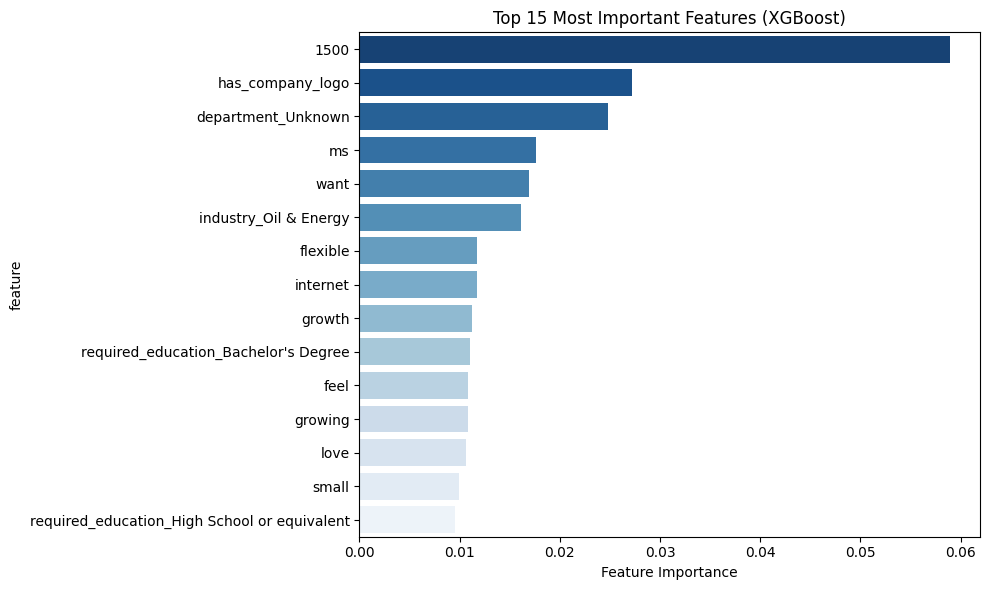

In [123]:
all_feature_names = list(X_struct.columns) + list(tfidf.get_feature_names_out())
importance_df = pd.DataFrame({
    'feature':    all_feature_names,
    'importance': xgb_model.feature_importances_
})
top_features = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='importance', y='feature', palette='Blues_r')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

**📊 Interpretation:** The top features reveal that the model relies heavily on **company logo presence** (the #1 structural predictor — fraudulent postings rarely include a logo) and multiple **TF-IDF text features** (specific words and phrases from job descriptions that correlate with fraud). Structured features like industry and employment type contribute secondary signal, confirming that both text content and job metadata are needed for strong fraud detection.

### 8.7 Cross-Validation

In [124]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='f1')
cv_roc = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')

print('5-Fold Cross-Validation Results (XGBoost):')
print(f'  F1  per fold: {cv_f1.round(3)}')
print(f'  F1  mean ± std: {cv_f1.mean():.3f} ± {cv_f1.std():.3f}')
print(f'  AUC per fold: {cv_roc.round(3)}')
print(f'  AUC mean ± std: {cv_roc.mean():.3f} ± {cv_roc.std():.3f}')

5-Fold Cross-Validation Results (XGBoost):
  F1  per fold: [0.731 0.769 0.811 0.811 0.689]
  F1  mean ± std: 0.762 ± 0.047
  AUC per fold: [0.941 0.971 0.973 0.969 0.94 ]
  AUC mean ± std: 0.959 ± 0.015


## 9. Save Model & Vectorizer

> Save all 3 files — the Flask API needs all of them.

In [127]:
joblib.dump(xgb_model,  'interface/xgb_model.pkl')
joblib.dump(tfidf,       'interface/tfidf_vectorizer.pkl')
joblib.dump(list(X_struct.columns), 'interface/model_features.pkl')
print('Saved: xgb_model.pkl, tfidf_vectorizer.pkl, model_features.pkl')

Saved: xgb_model.pkl, tfidf_vectorizer.pkl, model_features.pkl


## 10. Summary

### Model Comparison
| | Random Forest | Logistic Regression | XGBoost (Final) |
|---|---|---|---|
| Accuracy | 97% | 94% | **97%** |
| Fraud Precision | 100% | 53% | **87%** |
| Fraud Recall | 53% | 91% | **75%** |
| Fraud F1 | 0.69 | 0.67 | **0.80** ⭐ |
| Handles Imbalance | ✅ | ✅ | ✅ |
| Uses Text (TF-IDF) | ✅ | ✅ | ✅ |

### So we choose XGBoost 
- Best Fraud F1-score (0.80) — strongest balance of precision and recall
- Catches 75% of all fraudulent postings (vs 53% for Random Forest)
- When it flags fraud, it's correct 87% of the time (vs 53% for Logistic Regression)
- `scale_pos_weight=13` effectively handles the 93/7 class imbalance
